# Chapter 1 — Variational Autoencoder (2-D)

**Theory reference**: `quickguide.tex` Chapter 1.

### What this notebook covers
1. Generate 2-D toy datasets (spiral, moons, checkerboard)
2. Train a VAE with **2-D latent space** (so we can plot latent codes directly)
3. Visualize: ELBO loss, posterior collapse, latent scatter, interpolation, random samples

### Key equations
$$\mathcal{L}(\theta,\phi;x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{reconstruction}} - \underbrace{\mathrm{KL}(q_\phi(z|x)\|p(z))}_{\text{regularization}}$$

Reparameterization: $z = \mu_\phi(x) + \sigma_\phi(x)\odot\varepsilon$, $\varepsilon\sim\mathcal{N}(0,I)$.

Analytic KL: $\mathrm{KL}(\mathcal{N}(\mu,\sigma^2 I)\|\mathcal{N}(0,I)) = \tfrac{1}{2}\sum_i(\mu_i^2+\sigma_i^2-\log\sigma_i^2-1)$.

In [39]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


## 1  Datasets

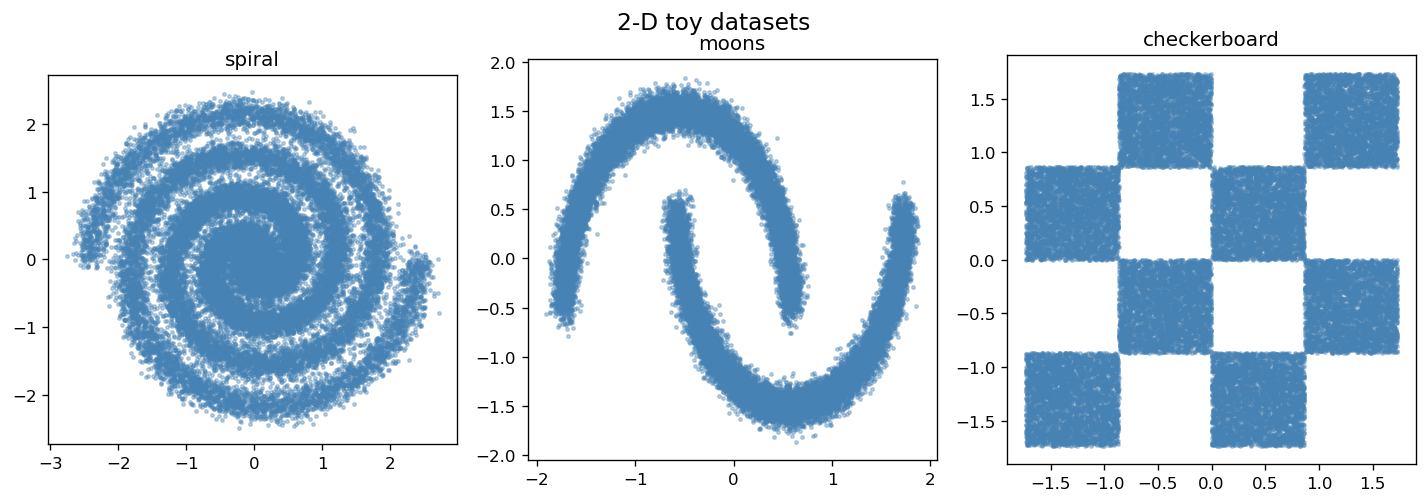

In [ ]:
from diffusion_lab.data import make_dataset, get_dataloader, DATASETS
from diffusion_lab.utils import compare_panels

DATASET = 'spiral'   # ← change to 'spiral' 'moons' or 'checkerboard'

# Quick visual of all three datasets
data_arrays = [make_dataset(n, n=30000, seed=0) for n in DATASETS]
compare_panels(*data_arrays, titles=list(DATASETS))
plt.suptitle('2-D toy datasets', fontsize=14, y=1.02)
plt.show()

In [41]:
# Build training loader for chosen dataset
N_TRAIN    = 20_000
BATCH_SIZE = 512
loader = get_dataloader(DATASET, n=N_TRAIN, batch_size=BATCH_SIZE,
                        seed=0, device=DEVICE)
x_all = torch.from_numpy(make_dataset(DATASET, n=N_TRAIN, seed=0)).to(DEVICE)

## 2  Model setup
Use **2-D latent** so we can plot the posterior directly.

In [42]:
from diffusion_lab.models.vae import VAE
from diffusion_lab.training import Trainer

model = VAE(
    in_dim    = 2,
    latent    = 2,      # 2-D latent → direct visualization
    hidden    = 256,
    depth     = 3,
    beta      = 1.0,    # standard VAE; try beta=4 for β-VAE
    rec_sigma = 0.05,   # tighter reconstruction for 2-D data
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'VAE parameters: {n_params:,}')

VAE parameters: 266,246


## 3  Training

In [43]:
N_STEPS = 5_000

trainer = Trainer(
    model    = model,
    loader   = loader,
    lr       = 3e-4,
    device   = DEVICE,
    grad_clip = 1.0,
)

losses = trainer.train(n_steps=N_STEPS, log_every=500)
print(f'\nInitial loss: {losses[0]:.4f}   Final loss: {losses[-1]:.4f}')

Training:   0%|          | 0/5000 [00:00<?, ?it/s]


Initial loss: 392.9841   Final loss: 7.0405


## 4  Loss curve

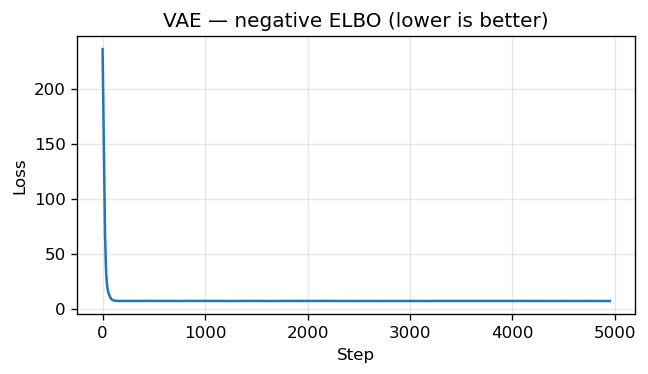

In [44]:
from diffusion_lab.utils import plot_loss_curve

plot_loss_curve(losses, smooth=50, title='VAE — negative ELBO (lower is better)')
plt.show()

## 5  Reconstruction quality

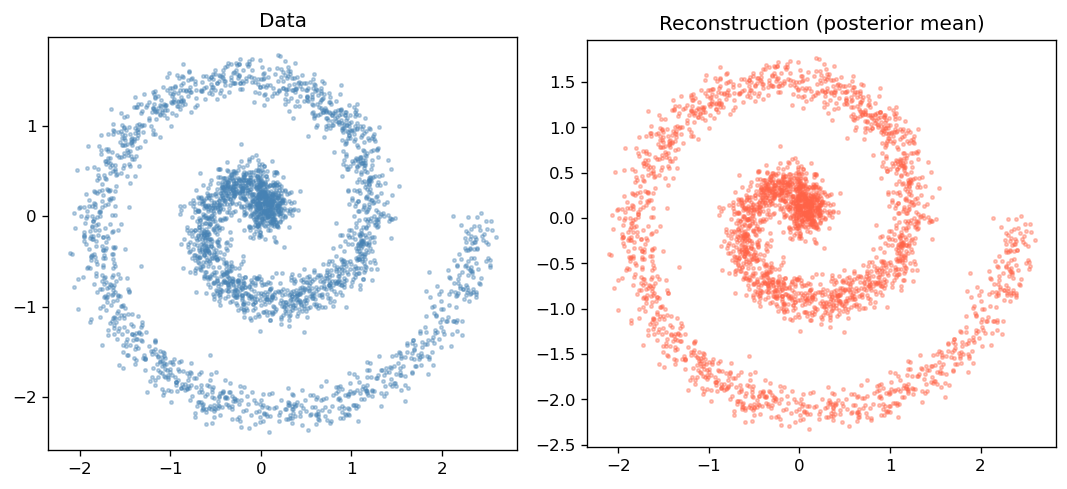

In [45]:
model.eval()
with torch.no_grad():
    x_test  = x_all[:3000]
    x_recon = model.reconstruct(x_test)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
from diffusion_lab.utils import plot_samples
plot_samples(x_test,  ax=axes[0], title='Data')
plot_samples(x_recon, ax=axes[1], title='Reconstruction (posterior mean)', color='tomato')
plt.tight_layout()
plt.show()

### Why does the reconstruction look identical?

Two compounding reasons:
1. **`rec_sigma=0.05` → loss weight = $\frac{1}{2\sigma^2}=200$** — even a 0.001 MSE costs 0.2 in the loss, so the model is forced into near-perfect reconstruction.
2. **`latent=2 == in_dim=2`** — no information bottleneck; the encoder can learn a lossless bijective mapping, making this behave like a deterministic autoencoder.

The cell below quantifies the error and shows the residuals.

MSE              : 0.000239
RMSE per point   : 0.015458  (data σ = 0.991)
Mean |error|     : 0.018766
Max  |error|     : 0.079985
Relative RMSE    : 1.5602% of data std


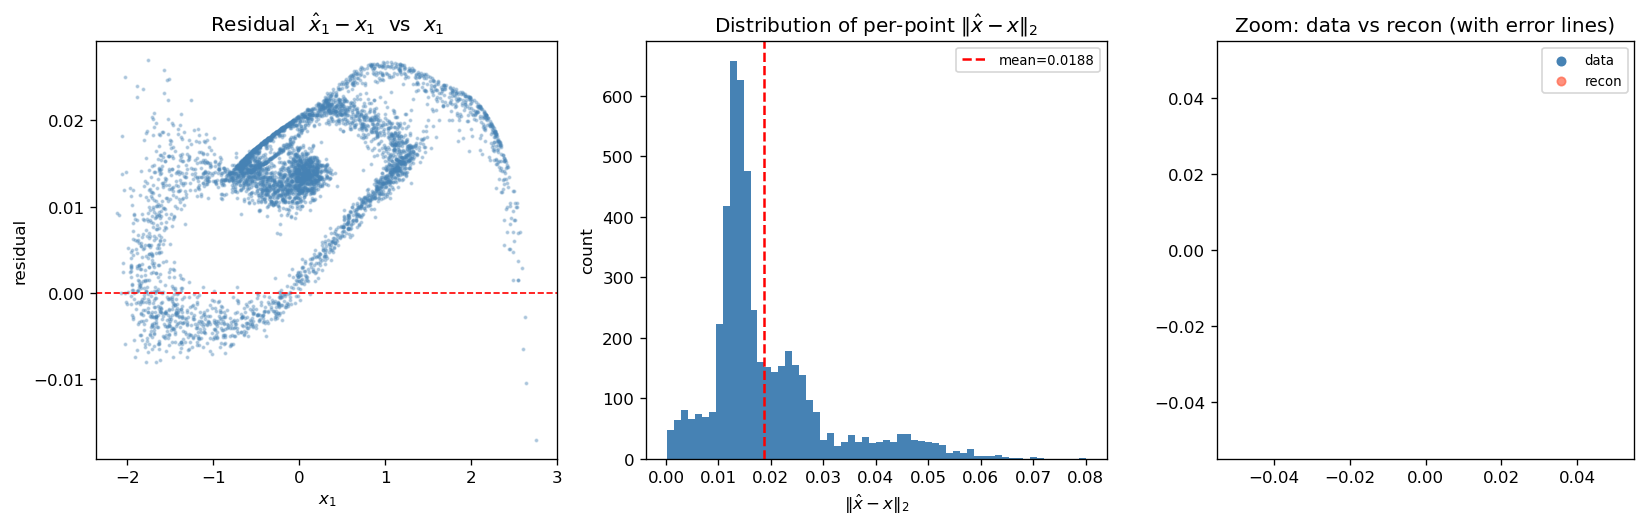

In [46]:
model.eval()
with torch.no_grad():
    x_test  = x_all[:5000]
    x_recon = model.reconstruct(x_test)
    residual = (x_recon - x_test).cpu().numpy()
    x_test_np  = x_test.cpu().numpy()
    x_recon_np = x_recon.cpu().numpy()

mse        = (residual ** 2).mean()
rmse       = mse ** 0.5
err_mag    = np.linalg.norm(residual, axis=1)   # per-point L2 error
data_range = x_test_np.std()

print(f"MSE              : {mse:.6f}")
print(f"RMSE per point   : {rmse:.6f}  (data σ = {data_range:.3f})")
print(f"Mean |error|     : {err_mag.mean():.6f}")
print(f"Max  |error|     : {err_mag.max():.6f}")
print(f"Relative RMSE    : {rmse / data_range * 100:.4f}% of data std")

# ── Visualise residuals ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Residual scatter (x1 component)
ax = axes[0]
ax.scatter(x_test_np[:, 0], residual[:, 0], s=2, alpha=0.3, color='steelblue')
ax.axhline(0, color='red', lw=1, ls='--')
ax.set_title('Residual  $\\hat{x}_1 - x_1$  vs  $x_1$')
ax.set_xlabel('$x_1$');  ax.set_ylabel('residual')

# Per-point error magnitude histogram
ax = axes[1]
ax.hist(err_mag, bins=60, color='steelblue', edgecolor='none')
ax.set_title('Distribution of per-point $\\|\\hat{x} - x\\|_2$')
ax.set_xlabel('$\\|\\hat{x} - x\\|_2$');  ax.set_ylabel('count')
ax.axvline(err_mag.mean(), color='red', lw=1.5, ls='--', label=f'mean={err_mag.mean():.4f}')
ax.legend(fontsize=8)

# Overlay: zoom into a small region to see errors
ax = axes[2]
mask = (np.abs(x_test_np[:, 0] - 0.5) < 0.15) & (np.abs(x_test_np[:, 1] - 0.5) < 0.15)
ax.scatter(x_test_np[mask, 0],  x_test_np[mask, 1],  s=25, color='steelblue', label='data',  zorder=3)
ax.scatter(x_recon_np[mask, 0], x_recon_np[mask, 1], s=25, color='tomato',    label='recon', zorder=4, alpha=0.7)
for i in np.where(mask)[0][:30]:
    ax.plot([x_test_np[i, 0], x_recon_np[i, 0]],
            [x_test_np[i, 1], x_recon_np[i, 1]], 'gray', lw=0.6, alpha=0.5)
ax.set_title('Zoom: data vs recon (with error lines)')
ax.legend(fontsize=8)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 6  Latent space scatter
Encode all data points and plot their posterior means in the 2-D latent space.

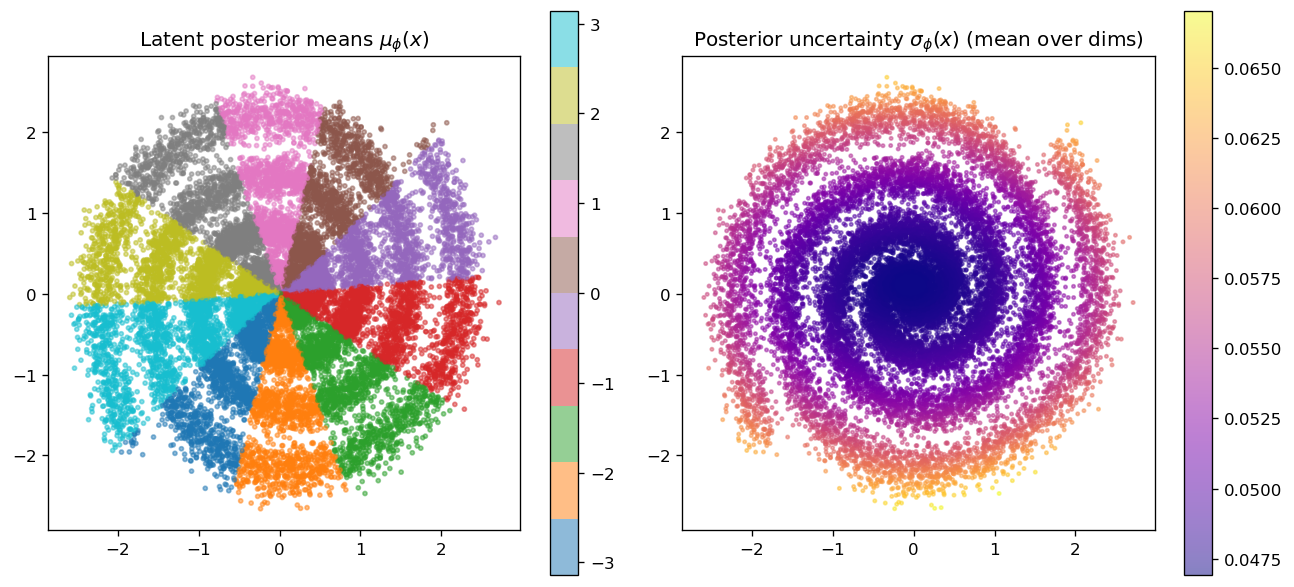

In [47]:
from diffusion_lab.utils import plot_latent_space

with torch.no_grad():
    mu_all, logvar_all = model.encode(x_all)

# Use the angle of each data point as a continuous label
labels = np.arctan2(x_all[:, 1].cpu().numpy(), x_all[:, 0].cpu().numpy())

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Latent means
plot_latent_space(mu_all, labels=labels, ax=axes[0],
                  title='Latent posterior means $\\mu_\\phi(x)$')

# Posterior std (how uncertain is the encoder?)
sigma_all = (0.5 * logvar_all).exp().cpu().numpy()
axes[1].scatter(mu_all[:, 0].cpu(), mu_all[:, 1].cpu(),
                c=sigma_all.mean(axis=1), cmap='plasma',
                s=4, alpha=0.5, rasterized=True)
axes[1].set_title('Posterior uncertainty $\\sigma_\\phi(x)$ (mean over dims)')
axes[1].set_aspect('equal')
plt.colorbar(axes[1].collections[0], ax=axes[1])

plt.tight_layout()
plt.show()

## 7  Random samples from the prior
$z \sim p(z) = \mathcal{N}(0,I)$, then decode.

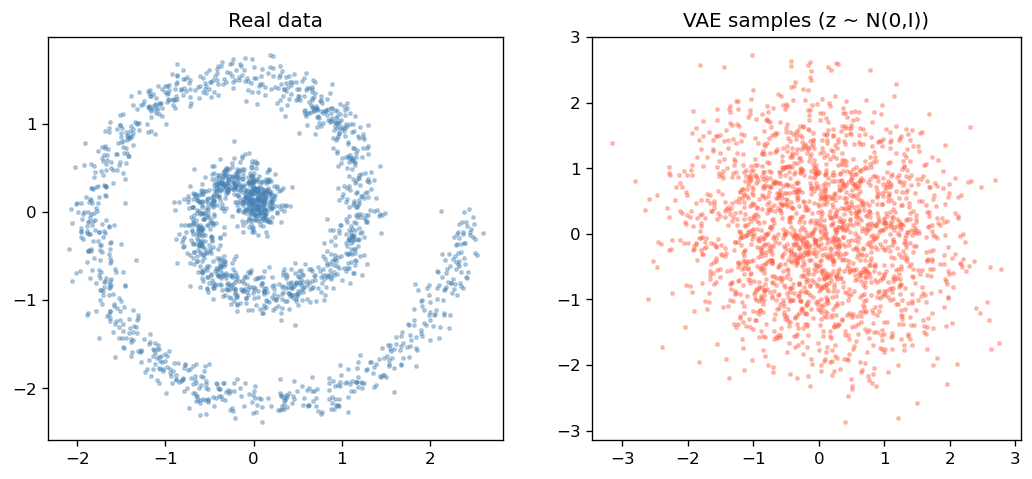

In [48]:
with torch.no_grad():
    x_gen = model.sample(2000, device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_samples(x_all[:2000], ax=axes[0], title='Real data')
plot_samples(x_gen,        ax=axes[1], title='VAE samples (z ~ N(0,I))', color='tomato')
plt.tight_layout()
plt.show()

## 8  Latent-space interpolation
Walk linearly from $z_a = \mu_\phi(x_a)$ to $z_b = \mu_\phi(x_b)$ in the latent space
and decode each intermediate point.

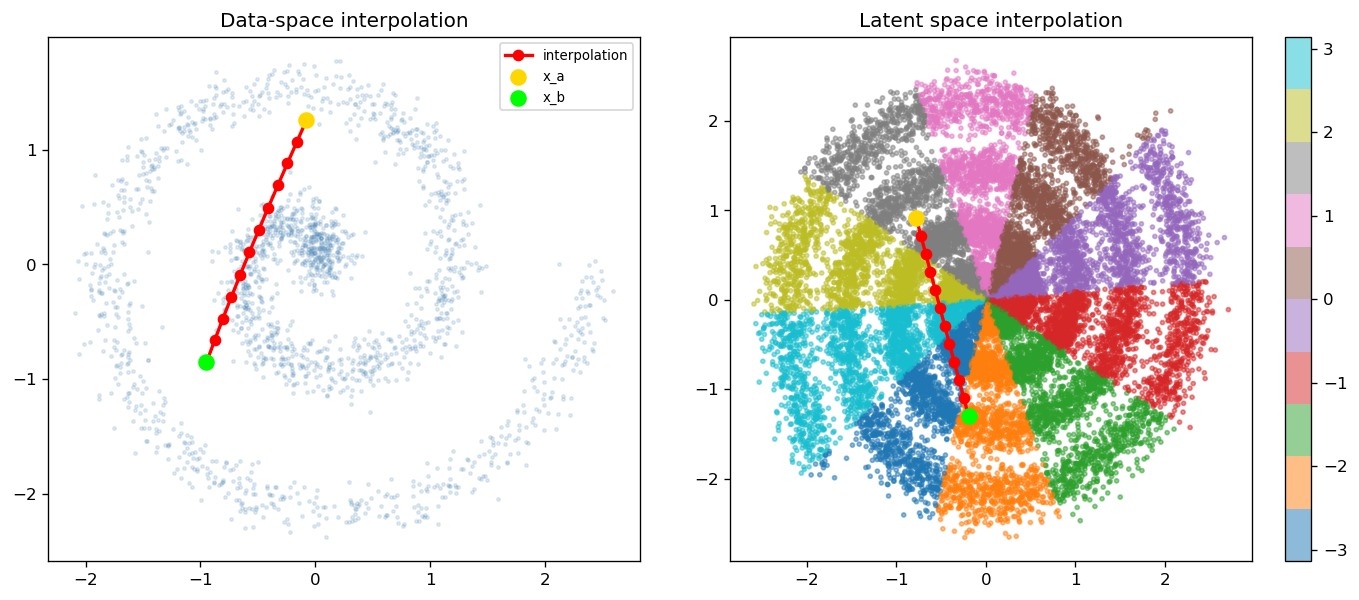

In [49]:
STEPS = 12

# Pick two well-separated data points
with torch.no_grad():
    x_a = x_all[0]
    x_b = x_all[N_TRAIN // 2]
    interp = model.interpolate(x_a, x_b, steps=STEPS)  # (STEPS, 2)
    z_a, _ = model.encode(x_a[None])
    z_b, _ = model.encode(x_b[None])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: data space interpolation path
ax = axes[0]
plot_samples(x_all[:2000], ax=ax, title='Data-space interpolation', alpha=0.15)
interp_np = interp.cpu().numpy()
ax.plot(interp_np[:, 0], interp_np[:, 1], 'o-', color='red',
        markersize=6, linewidth=2, zorder=5, label='interpolation')
ax.scatter(*x_a.cpu(), s=80, c='gold', zorder=6, label='x_a')
ax.scatter(*x_b.cpu(), s=80, c='lime', zorder=6, label='x_b')
ax.legend(fontsize=8)

# Right: latent space
ax = axes[1]
plot_latent_space(mu_all, labels=labels, ax=ax,
                  title='Latent space interpolation')
alphas = np.linspace(0, 1, STEPS)
z_line = (1 - alphas[:, None]) * z_a.cpu().numpy() + alphas[:, None] * z_b.cpu().numpy()
ax.plot(z_line[:, 0], z_line[:, 1], 'o-', color='red',
        markersize=6, linewidth=2, zorder=5)
ax.scatter(*z_a.cpu().numpy().flatten(), s=80, c='gold', zorder=6)
ax.scatter(*z_b.cpu().numpy().flatten(), s=80, c='lime',  zorder=6)

plt.tight_layout()
plt.show()

## 9  β-VAE ablation
Higher β enforces a more disentangled / compressed latent space at the cost of reconstruction quality.

Training:   0%|          | 0/2000 [00:00<?, ?it/s]

β=0.1 done


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

β=1.0 done


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

β=4.0 done


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

β=10.0 done


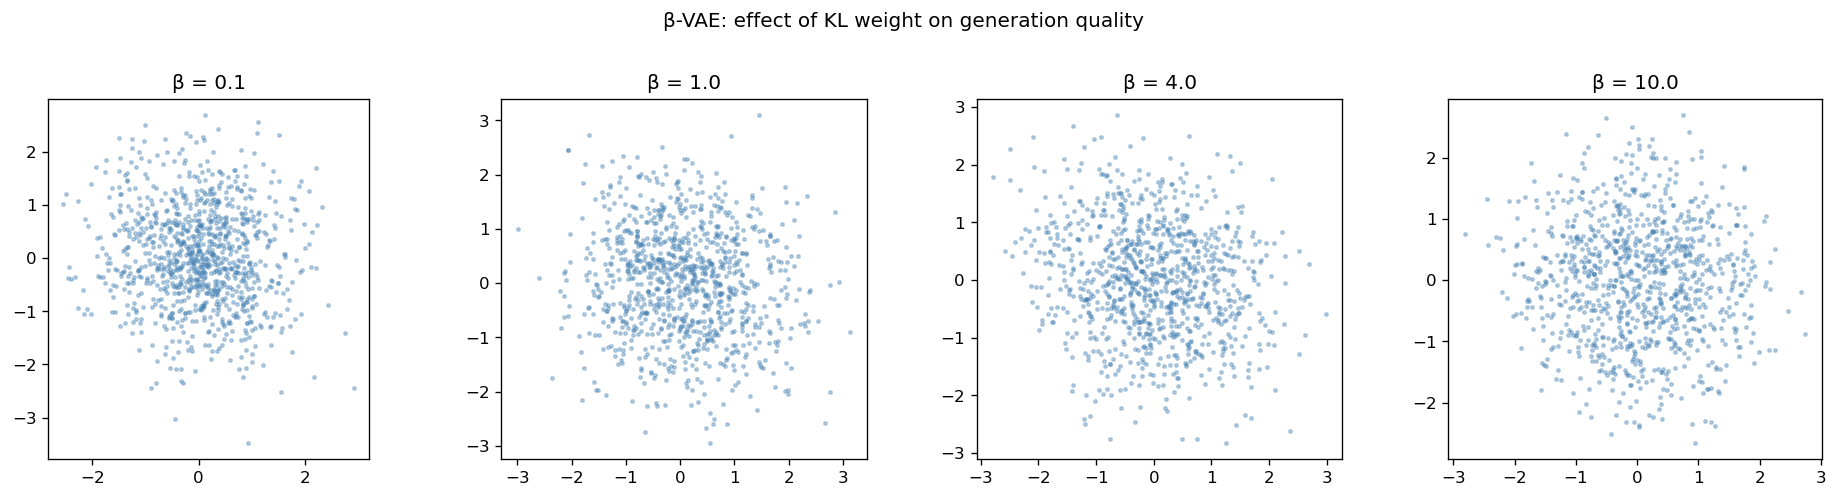

In [50]:
betas   = [0.1, 1.0, 4.0, 10.0]
samples = {}

for beta in betas:
    m = VAE(in_dim=2, latent=2, hidden=128, depth=3,
            beta=beta, rec_sigma=0.05).to(DEVICE)
    tr = Trainer(m, loader, lr=3e-4, device=DEVICE, grad_clip=1.0)
    tr.train(n_steps=2000, log_every=10000)   # quiet
    m.eval()
    with torch.no_grad():
        samples[beta] = m.sample(1000, device=DEVICE).cpu().numpy()
    print(f'β={beta:.1f} done')

fig, axes = plt.subplots(1, len(betas), figsize=(4 * len(betas), 4))
for ax, beta in zip(axes, betas):
    plot_samples(samples[beta], ax=ax, title=f'β = {beta}', color='steelblue')
plt.suptitle('β-VAE: effect of KL weight on generation quality', y=1.02)
plt.tight_layout()
plt.show()

## 10  Decoder manifold — how latent grid maps to data space

A regular grid of $z$ values is decoded through $p_\theta(x|z)$.
- **Left**: latent grid (input), colored by angular position
- **Middle**: decoded points in data space (same colors) — reveals how the decoder "warps" the latent plane
- **Right**: decoded grid overlaid on real data — shows coverage and alignment

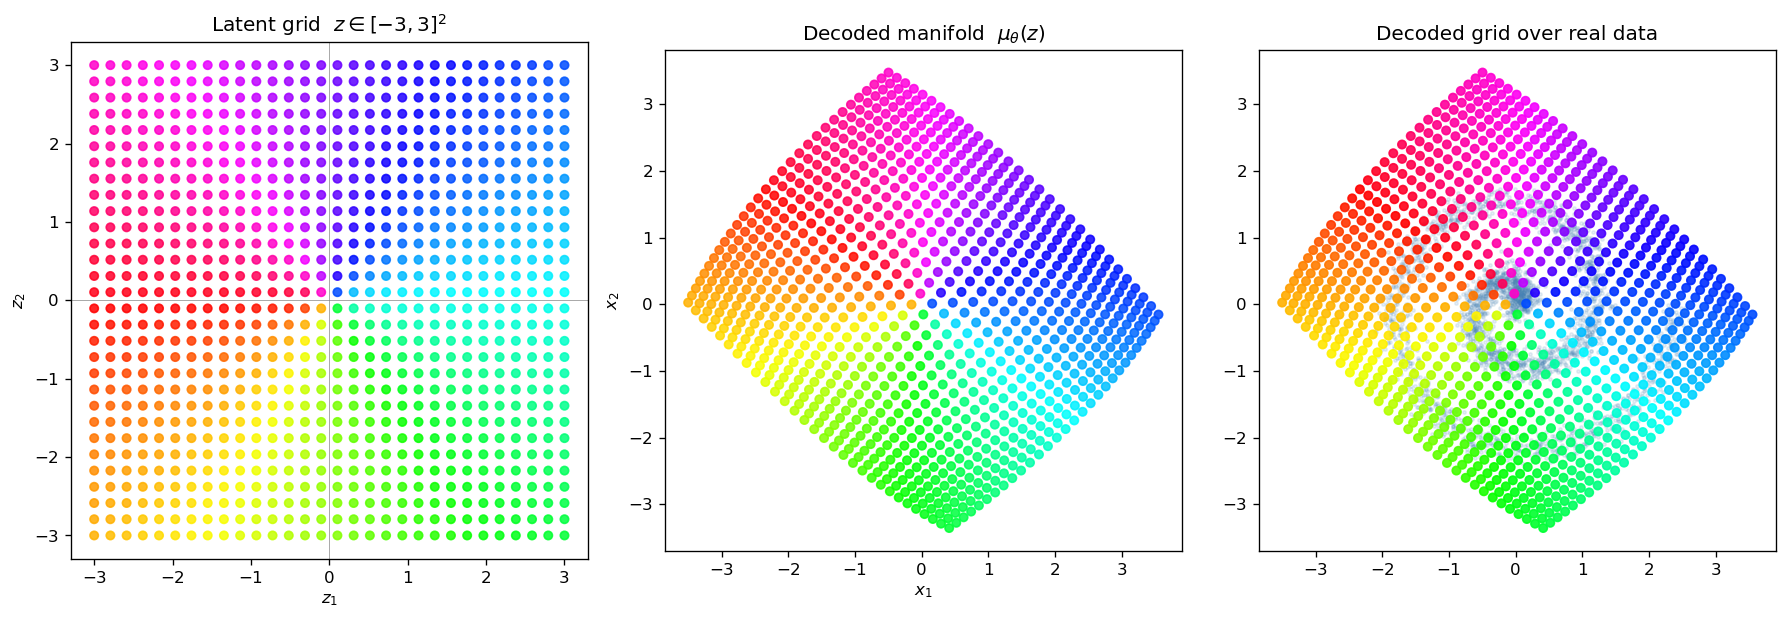

In [51]:
model.eval()

RESOLUTION = 30
LIM = 3.0

z1 = torch.linspace(-LIM, LIM, RESOLUTION)
z2 = torch.linspace(-LIM, LIM, RESOLUTION)
Z1, Z2 = torch.meshgrid(z1, z2, indexing='ij')
z_grid = torch.stack([Z1.flatten(), Z2.flatten()], dim=1).to(DEVICE)

with torch.no_grad():
    x_decoded = model.decode(z_grid).cpu().numpy()

z_grid_np = z_grid.cpu().numpy()
color = np.arctan2(z_grid_np[:, 1], z_grid_np[:, 0])   # hue = angle in latent space

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: latent grid
ax = axes[0]
ax.scatter(z_grid_np[:, 0], z_grid_np[:, 1], c=color, cmap='hsv', s=25, alpha=0.85)
ax.axhline(0, color='gray', lw=0.4)
ax.axvline(0, color='gray', lw=0.4)
ax.set_title('Latent grid  $z \\in [-3,3]^2$')
ax.set_xlabel('$z_1$');  ax.set_ylabel('$z_2$')
ax.set_aspect('equal')

# ── Panel 2: decoded manifold
ax = axes[1]
ax.scatter(x_decoded[:, 0], x_decoded[:, 1], c=color, cmap='hsv', s=25, alpha=0.85)
ax.set_title('Decoded manifold  $\\mu_\\theta(z)$')
ax.set_xlabel('$x_1$');  ax.set_ylabel('$x_2$')
ax.set_aspect('equal')

# ── Panel 3: manifold over real data
ax = axes[2]
plot_samples(x_all[:3000], ax=ax, title='Decoded grid over real data', alpha=0.12)
ax.scatter(x_decoded[:, 0], x_decoded[:, 1], c=color, cmap='hsv', s=25, alpha=0.9, zorder=5)

plt.tight_layout()
plt.show()

## 11  Prior vs posterior — density in latent space

The KL term pushes $q_\phi(z|x) \approx \mathcal{N}(0,I)$.  
Here we compare the aggregate posterior $\frac{1}{N}\sum_i q_\phi(z|x_i)$ against the prior via a 2-D KDE heatmap.

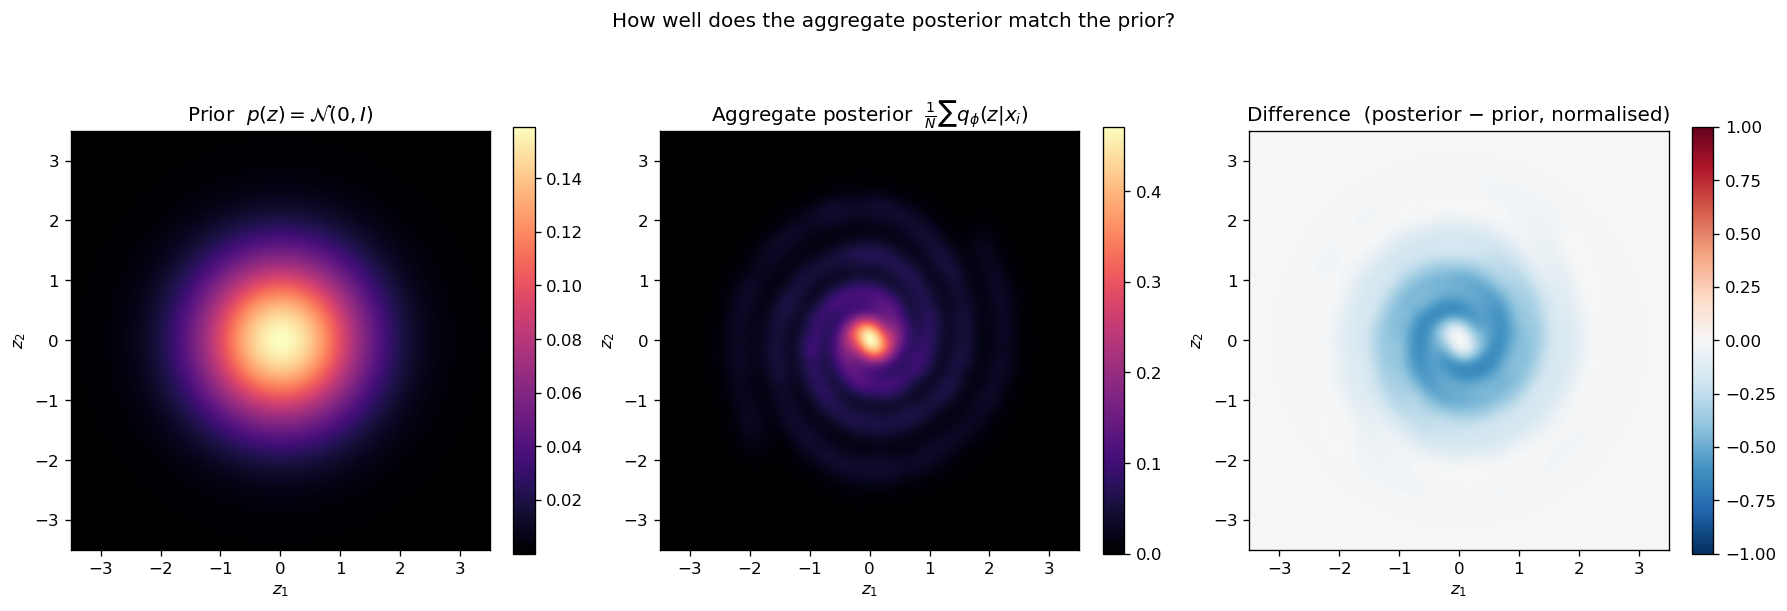

In [52]:
from scipy.stats import gaussian_kde

mu_np = mu_all.cpu().numpy()          # posterior means  (N, 2)

# 2-D KDE grid
grid_pts = 200
lim_kde  = 3.5
xx = np.linspace(-lim_kde, lim_kde, grid_pts)
yy = np.linspace(-lim_kde, lim_kde, grid_pts)
XX, YY = np.meshgrid(xx, yy)
grid_flat = np.vstack([XX.ravel(), YY.ravel()])

# Posterior KDE (aggregate over μ values)
kde_post = gaussian_kde(mu_np.T, bw_method=0.15)
Z_post   = kde_post(grid_flat).reshape(grid_pts, grid_pts)

# Prior N(0,I) density
from scipy.stats import multivariate_normal
Z_prior = multivariate_normal(mean=[0, 0], cov=np.eye(2)).pdf(
    np.dstack([XX, YY])
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

kw = dict(origin='lower', extent=[-lim_kde, lim_kde, -lim_kde, lim_kde],
          aspect='equal', cmap='magma')

# Prior
im0 = axes[0].imshow(Z_prior, **kw)
axes[0].set_title('Prior  $p(z) = \\mathcal{N}(0,I)$')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Aggregate posterior
im1 = axes[1].imshow(Z_post, **kw)
axes[1].set_title('Aggregate posterior  $\\frac{1}{N}\\sum q_\\phi(z|x_i)$')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Difference  (posterior − prior, normalised)
Z_diff = Z_post / Z_post.max() - Z_prior / Z_prior.max()
im2 = axes[2].imshow(Z_diff, origin='lower',
                     extent=[-lim_kde, lim_kde, -lim_kde, lim_kde],
                     aspect='equal', cmap='RdBu_r',
                     vmin=-1, vmax=1)
axes[2].set_title('Difference  (posterior − prior, normalised)')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel('$z_1$');  ax.set_ylabel('$z_2$')

plt.suptitle('How well does the aggregate posterior match the prior?', y=1.02)
plt.tight_layout()
plt.show()